# Exploratory Data Analysis

## Objectives

The purpose of this notebook is to explore the cleaned airline passenger satisfaction dataset and identify patterns and relationships that may help explain passenger satisfaction.

The analysis will focus on:

- Overall passenger satisfaction.
- Passenger demographic characteristics.
- Customer type.
- Type of travel and travel class.
- Flight distance.
- Airline service ratings.
- Departure and arrival delays.
- Relationships between numerical variables.

The findings from this exploratory analysis will be used to support the statistical analysis, machine-learning modelling and business recommendations developed later in the project.

## Load the Cleaned Dataset

The cleaned dataset produced during the data-cleaning stage will be used for the exploratory analysis.

Using the cleaned dataset ensures that the EDA is performed on the validated data after the identified missing values, duplicates and unnecessary columns have been addressed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/clean_data/airline_clean.csv")

df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [2]:
df.shape

(103594, 23)

## Dataset Overview

The cleaned dataset contains passenger demographic information, travel characteristics, airline service ratings, flight delay information and the passenger satisfaction outcome.

The dataset structure is examined below to understand the available variables and their data types before conducting the detailed exploratory analysis.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103594 entries, 0 to 103593
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             103594 non-null  object 
 1   Customer Type                      103594 non-null  object 
 2   Age                                103594 non-null  int64  
 3   Type of Travel                     103594 non-null  object 
 4   Class                              103594 non-null  object 
 5   Flight Distance                    103594 non-null  int64  
 6   Inflight wifi service              103594 non-null  int64  
 7   Departure/Arrival time convenient  103594 non-null  int64  
 8   Ease of Online booking             103594 non-null  int64  
 9   Gate location                      103594 non-null  int64  
 10  Food and drink                     103594 non-null  int64  
 11  Online boarding                    1035

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Gender,103594,2,Female,52576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Type,103594,2,Loyal Customer,84662,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,103594.0,NaN,NaN,NaN,39.380466,15.113125,7.0,27.0,40.0,51.0,85.0
Type of Travel,103594,2,Business travel,71465,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class,103594,3,Business,49533,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flight Distance,103594.0,NaN,NaN,NaN,1189.325202,997.297235,31.0,414.0,842.0,1743.0,4983.0
Inflight wifi service,103594.0,NaN,NaN,NaN,2.729753,1.327866,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,103594.0,NaN,NaN,NaN,3.060081,1.525233,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,103594.0,NaN,NaN,NaN,2.756984,1.398934,0.0,2.0,3.0,4.0,5.0
Gate location,103594.0,NaN,NaN,NaN,2.977026,1.277723,0.0,2.0,3.0,4.0,5.0


### Numerical Variables

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,103594.0,39.380466,15.113125,7.0,27.0,40.0,51.0,85.0
Flight Distance,103594.0,1189.325202,997.297235,31.0,414.0,842.0,1743.0,4983.0
Inflight wifi service,103594.0,2.729753,1.327866,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,103594.0,3.060081,1.525233,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,103594.0,2.756984,1.398934,0.0,2.0,3.0,4.0,5.0
Gate location,103594.0,2.977026,1.277723,0.0,2.0,3.0,4.0,5.0
Food and drink,103594.0,3.202126,1.329401,0.0,2.0,3.0,4.0,5.0
Online boarding,103594.0,3.250497,1.349433,0.0,2.0,3.0,4.0,5.0
Seat comfort,103594.0,3.439765,1.318896,0.0,2.0,4.0,5.0,5.0
Inflight entertainment,103594.0,3.358341,1.333030,0.0,2.0,4.0,4.0,5.0


---

## Passenger Satisfaction Distribution

The first stage of the exploratory analysis examines the overall distribution of passenger satisfaction.

Understanding the proportion of satisfied and neutral/dissatisfied passengers provides a baseline view of the customer experience in the dataset.

### Satisfaction Distribution

The distribution of passenger satisfaction is visualised below to make the overall pattern easier to interpret.

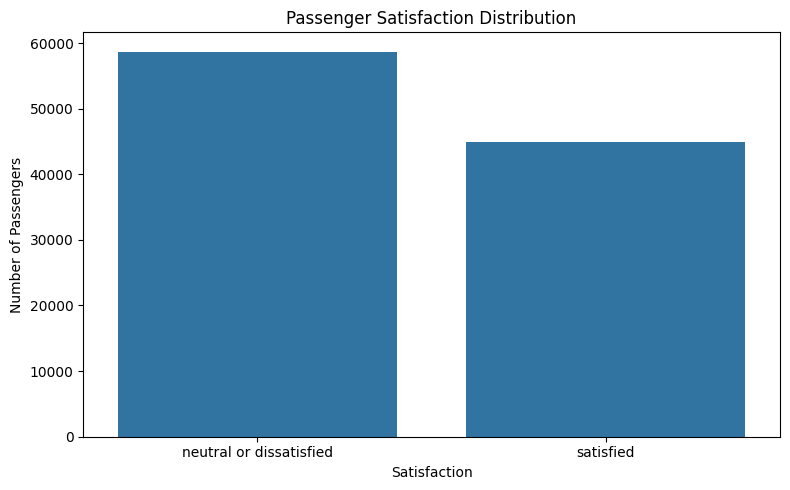

In [6]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="satisfaction",
    order=df["satisfaction"].value_counts().index
)

plt.title("Passenger Satisfaction Distribution")
plt.xlabel("Satisfaction")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()

### Finding

The satisfaction distribution shows the overall balance between satisfied and neutral/dissatisfied passengers in the dataset.

This provides the baseline for the remaining exploratory analysis. Differences between passenger groups, travel characteristics, service ratings and delays can then be compared against these overall satisfaction patterns.

## Passenger Characteristics

Passenger characteristics are explored to determine whether satisfaction patterns differ between demographic and customer groups.

### Satisfaction by Gender

The relationship between gender and passenger satisfaction is examined to identify whether the distribution of satisfaction differs between male and female passengers.

In [7]:
gender_satisfaction = pd.crosstab(
    df["Gender"],
    df["satisfaction"],
    normalize="index"
) * 100

gender_satisfaction.round(2)

satisfaction,neutral or dissatisfied,satisfied
Gender,,
Female,57.26,42.74
Male,56.04,43.96


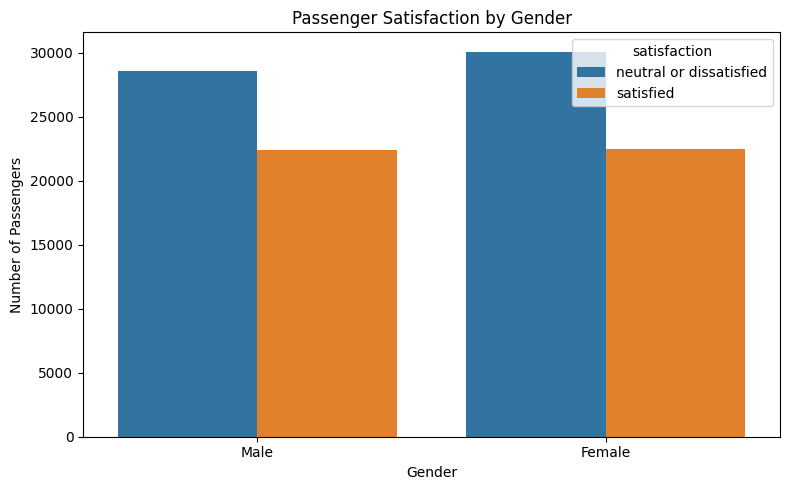

In [8]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Gender",
    hue="satisfaction"
)

plt.title("Passenger Satisfaction by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()

### Finding

The gender comparison shows whether the proportion of satisfied and neutral/dissatisfied passengers differs between the two gender groups.

The observed differences are explored descriptively at this stage. Statistical testing is used later in the project where appropriate to determine whether relationships are statistically significant.

## Age Distribution and Satisfaction

Age is examined to understand the demographic profile of passengers and whether passenger age shows differences across satisfaction groups.

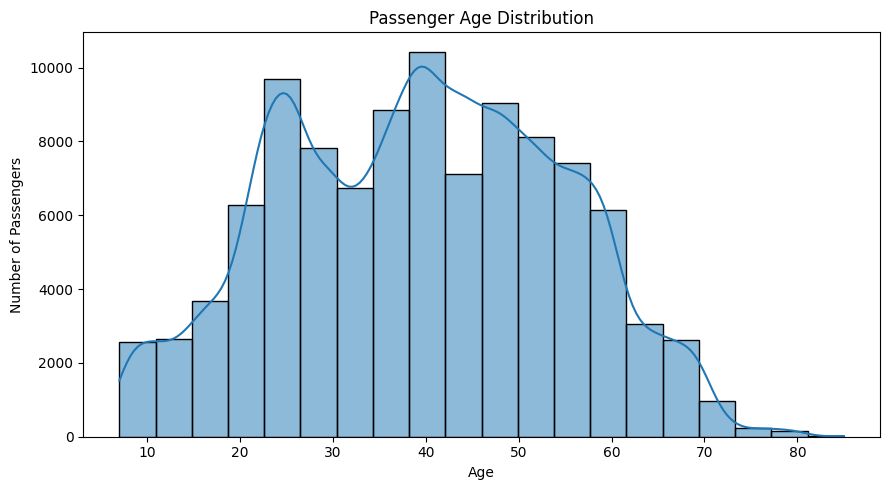

In [9]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True
)

plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()

In [10]:
age_satisfaction = (
    df.groupby("satisfaction")["Age"]
    .agg(["mean", "median", "std"])
    .round(2)
)

age_satisfaction

,mean,median,std
satisfaction,,,
neutral or dissatisfied,37.57,36.0,16.46
satisfied,41.75,43.0,12.77


### Finding

The age distribution shows the range and concentration of passenger ages in the dataset.

Comparing the mean, median and standard deviation of age across satisfaction groups helps identify whether the passenger age profile differs between satisfied and neutral/dissatisfied passengers.

These observations describe patterns in the dataset and do not by themselves establish a statistically significant relationship.

### Satisfaction by Customer Type

Customer type is examined to determine whether returning and first-time passengers show different satisfaction patterns.

In [11]:
customer_satisfaction = pd.crosstab(
    df["Customer Type"],
    df["satisfaction"],
    normalize="index"
) * 100

customer_satisfaction.round(2)

satisfaction,neutral or dissatisfied,satisfied
Customer Type,,
Loyal Customer,52.27,47.73
disloyal Customer,76.32,23.68


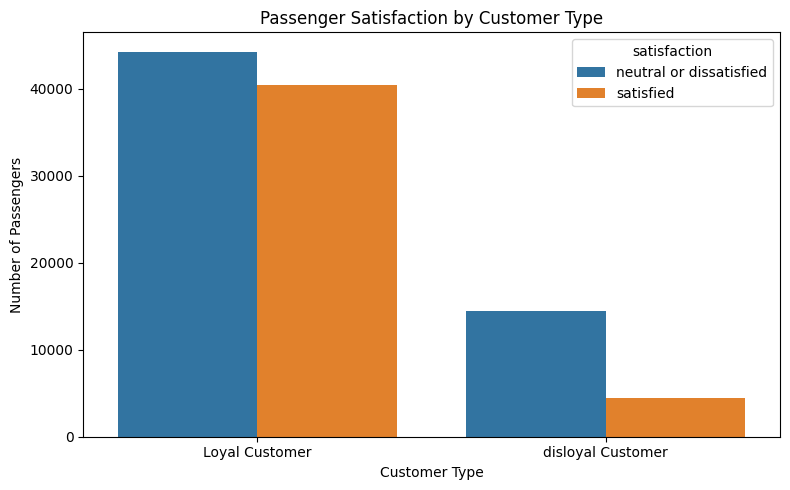

In [12]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Customer Type",
    hue="satisfaction"
)

plt.title("Passenger Satisfaction by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()

### Finding

The comparison shows how satisfaction is distributed between the different customer types.

The results provide an initial descriptive view of whether customer loyalty or passenger type may be associated with satisfaction. Any observed differences should be interpreted as patterns in the data rather than evidence of causation.

### Satisfaction by Type of Travel and Travel Class

Type of Travel and Travel Class are examined to determine whether passenger satisfaction differs across different travel groups.

In [13]:
travel_satisfaction = pd.crosstab(
    df["Type of Travel"],
    df["satisfaction"],
    normalize="index"
) * 100

travel_satisfaction.round(2)

satisfaction,neutral or dissatisfied,satisfied
Type of Travel,,
Business travel,41.74,58.26
Personal Travel,89.84,10.16


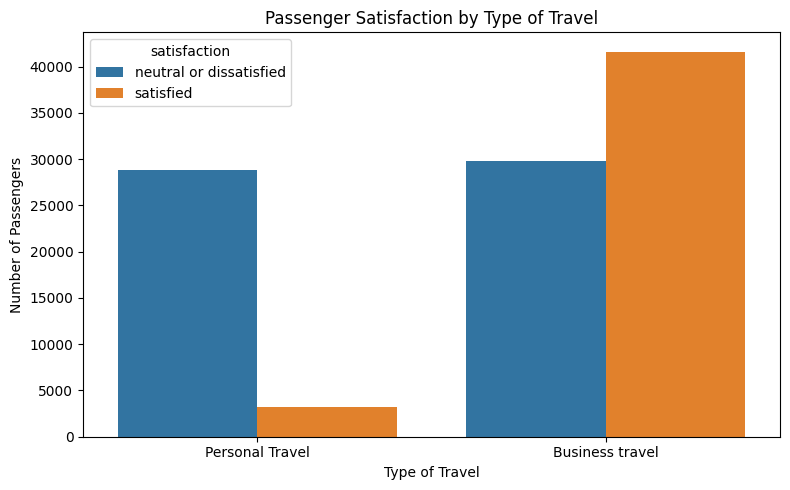

In [14]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Type of Travel",
    hue="satisfaction"
)

plt.title("Passenger Satisfaction by Type of Travel")
plt.xlabel("Type of Travel")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()

### Satisfaction by Travel Class

Travel class is examined to identify whether passengers travelling in different classes show different satisfaction patterns.

In [15]:
class_satisfaction = pd.crosstab(
    df["Class"],
    df["satisfaction"],
    normalize="index"
) * 100

class_satisfaction.round(2)

satisfaction,neutral or dissatisfied,satisfied
Class,,
Business,30.57,69.43
Eco,81.39,18.61
Eco Plus,75.42,24.58


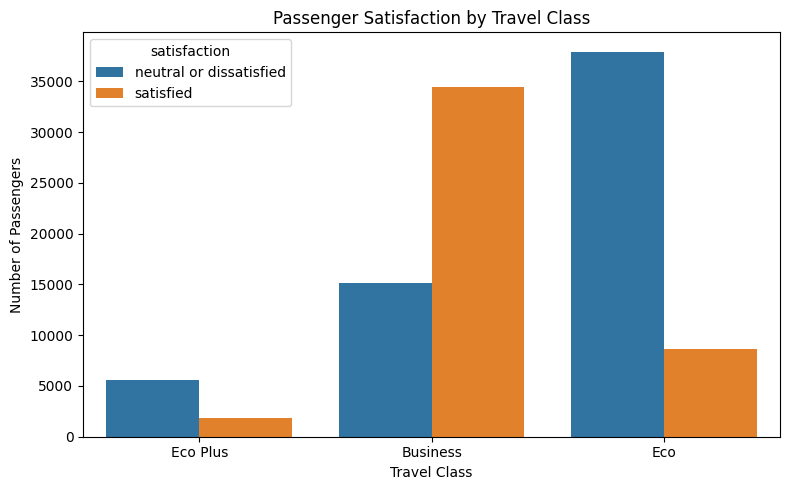

In [16]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Class",
    hue="satisfaction"
)

plt.title("Passenger Satisfaction by Travel Class")
plt.xlabel("Travel Class")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()

### Finding

The analysis shows how passenger satisfaction varies across different types of travel and travel classes.

These descriptive differences provide an initial indication of whether travel characteristics may be associated with passenger satisfaction. The relationship between Type of Travel and satisfaction is examined statistically later in the project using a Chi-square test.

## Flight Distance

Flight distance is examined to understand the range of journeys represented in the dataset and whether passengers travelling different distances show different satisfaction patterns.

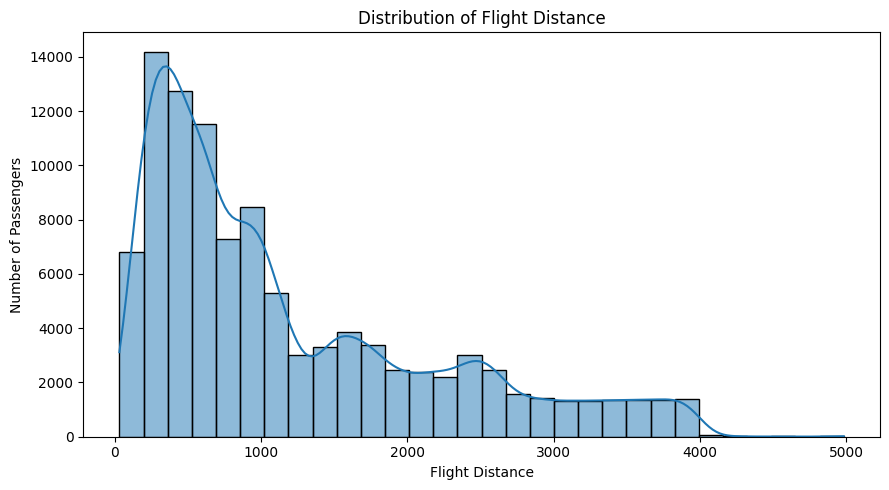

In [17]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Flight Distance",
    bins=30,
    kde=True
)

plt.title("Distribution of Flight Distance")
plt.xlabel("Flight Distance")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()

In [18]:
flight_distance_satisfaction = (
    df.groupby("satisfaction")["Flight Distance"]
    .agg(["mean", "median", "std"])
    .round(2)
)

flight_distance_satisfaction

,mean,median,std
satisfaction,,,
neutral or dissatisfied,928.61,671.0,790.41
satisfied,1530.18,1250.0,1128.32


### Finding

The flight-distance distribution shows the range and concentration of journey lengths in the dataset.

Comparing flight distance across satisfaction groups provides an initial indication of whether journey length may be associated with passenger satisfaction. This is a descriptive comparison and does not establish causation.

### Flight Delays

Departure and arrival delays are examined to understand their distribution and to investigate whether passengers experiencing different levels of delay show different satisfaction patterns.

In [19]:
delay_summary = (
    df[
        [
            "Departure Delay in Minutes",
            "Arrival Delay in Minutes"
        ]
    ]
    .describe()
    .T
    .round(2)
)

delay_summary

,count,mean,std,min,25%,50%,75%,max
Departure Delay in Minutes,103594.0,14.75,38.12,0.0,0.0,0.0,12.0,1592.0
Arrival Delay in Minutes,103594.0,15.18,38.70,0.0,0.0,0.0,13.0,1584.0


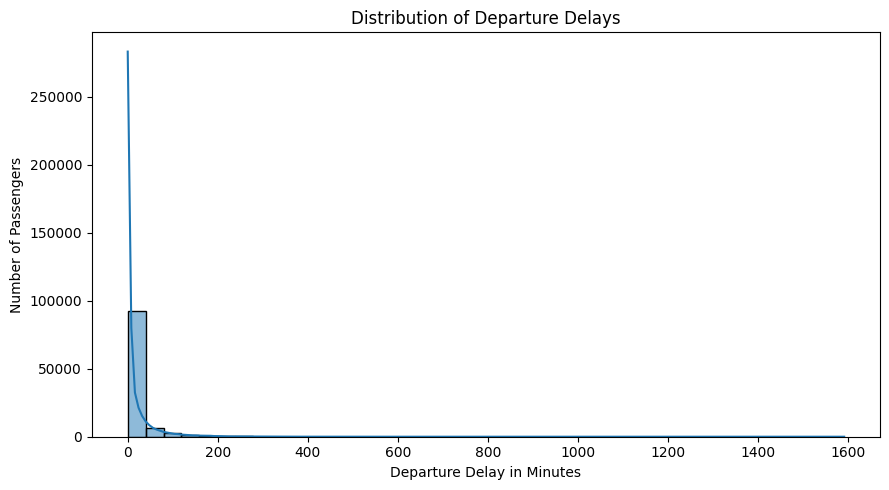

In [20]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Departure Delay in Minutes",
    bins=40,
    kde=True
)

plt.title("Distribution of Departure Delays")
plt.xlabel("Departure Delay in Minutes")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()

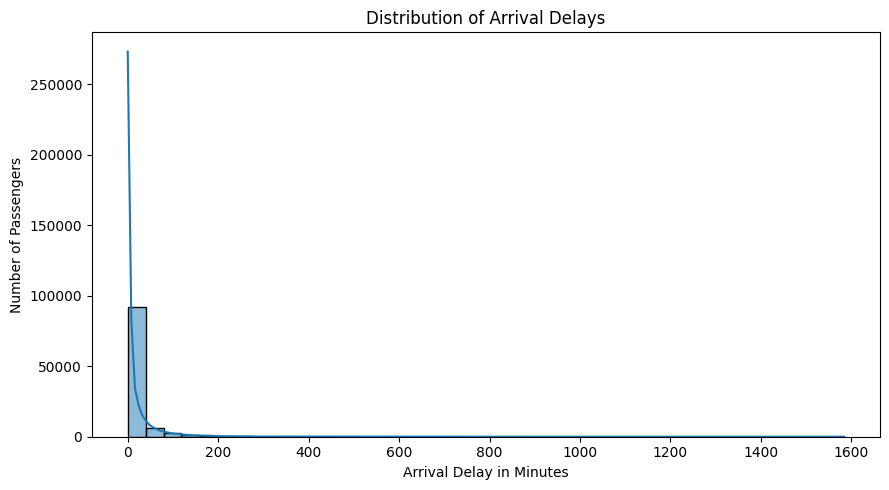

In [21]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Arrival Delay in Minutes",
    bins=40,
    kde=True
)

plt.title("Distribution of Arrival Delays")
plt.xlabel("Arrival Delay in Minutes")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()

In [22]:
delay_by_satisfaction = (
    df.groupby("satisfaction")[
        [
            "Departure Delay in Minutes",
            "Arrival Delay in Minutes"
        ]
    ]
    .agg(["mean", "median"])
    .round(2)
)

delay_by_satisfaction

Departure Delay in Minutes         \
                                              mean median   
satisfaction                                                
neutral or dissatisfied                      16.43    0.0   
satisfied                                    12.55    0.0   

                        Arrival Delay in Minutes         
                                            mean median  
satisfaction                                             
neutral or dissatisfied                    17.13    0.0  
satisfied                                  12.63    0.0

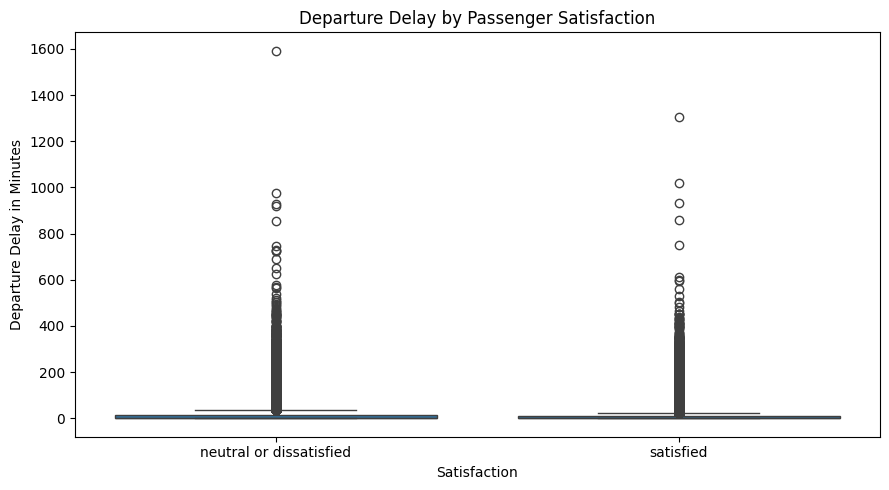

In [23]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="satisfaction",
    y="Departure Delay in Minutes"
)

plt.title("Departure Delay by Passenger Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Departure Delay in Minutes")
plt.tight_layout()
plt.show()

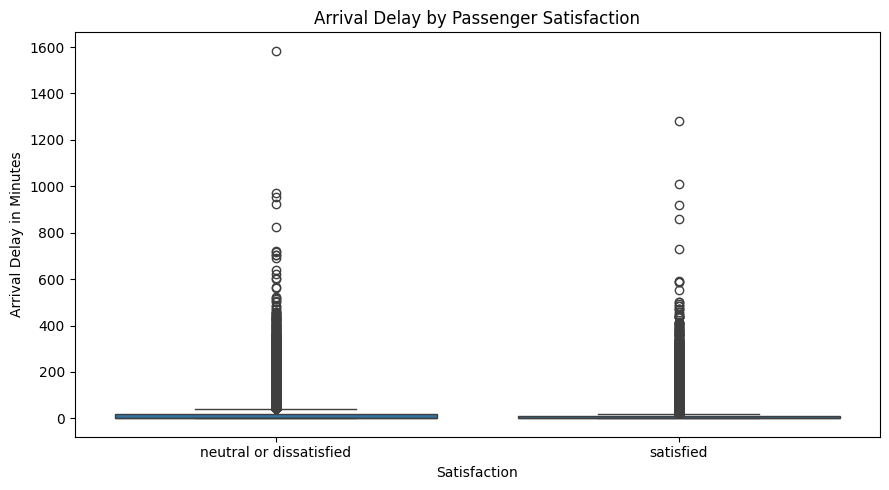

In [24]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="satisfaction",
    y="Arrival Delay in Minutes"
)

plt.title("Arrival Delay by Passenger Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Arrival Delay in Minutes")
plt.tight_layout()
plt.show()

### Finding

The delay analysis shows the distribution and variability of departure and arrival delays and compares delay levels between passenger satisfaction groups.

The descriptive results provide an initial indication of whether passengers experiencing different levels of delay also show different satisfaction patterns. Statistical testing is used separately to determine whether observed differences are statistically significant.

## Airline Service Ratings

Airline service ratings are examined to identify which areas of the passenger experience show the largest differences between satisfied and neutral/dissatisfied passengers.

The analysis focuses on service areas including online services, seat comfort, food and drink, inflight entertainment, leg room, baggage handling, check-in, inflight service and cleanliness.

In [25]:
service_columns = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness"
]

In [26]:
service_means = (
    df.groupby("satisfaction")[service_columns]
    .mean()
    .T
    .round(2)
)

service_means

satisfaction,neutral or dissatisfied,satisfied
Inflight wifi service,2.40,3.16
Departure/Arrival time convenient,3.13,2.97
Ease of Online booking,2.55,3.03
Gate location,2.98,2.98
Food and drink,2.96,3.52
Online boarding,2.66,4.03
Seat comfort,3.04,3.97
Inflight entertainment,2.89,3.97
On-board service,3.02,3.86
Leg room service,2.99,3.82


In [27]:
service_difference = (
    service_means["satisfied"]
    - service_means["neutral or dissatisfied"]
).sort_values(ascending=False)

service_difference.round(2)

Online boarding                      1.37
Inflight entertainment               1.08
Seat comfort                         0.93
On-board service                     0.84
Leg room service                     0.83
Cleanliness                          0.80
Inflight wifi service                0.76
Checkin service                      0.61
Baggage handling                     0.59
Inflight service                     0.58
Food and drink                       0.56
Ease of Online booking               0.48
Gate location                        0.00
Departure/Arrival time convenient   -0.16
dtype: float64

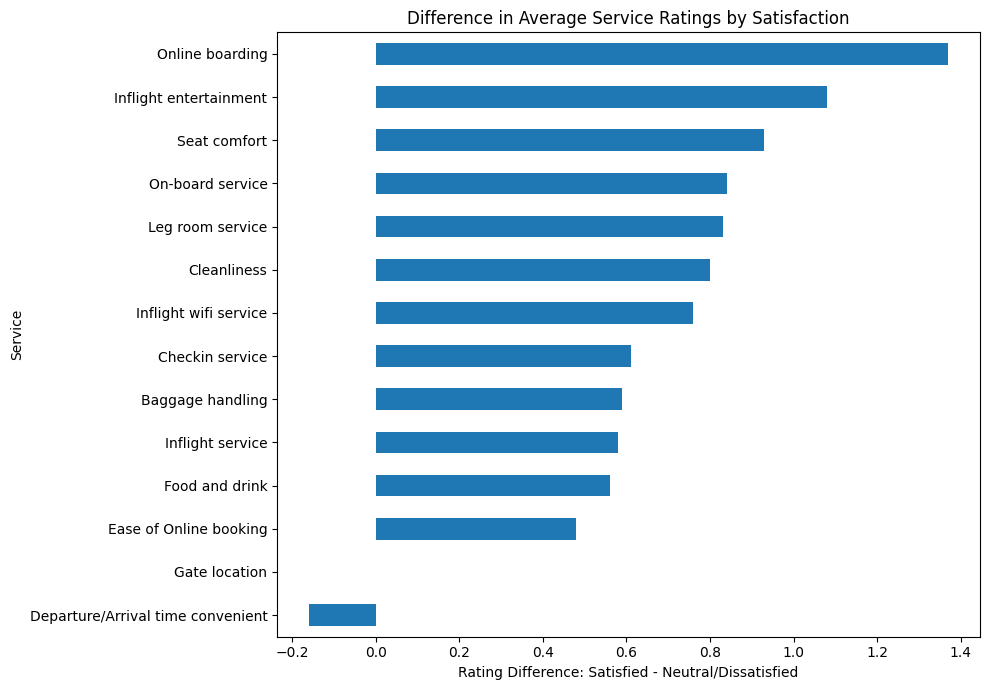

In [28]:
plt.figure(figsize=(10, 7))

service_difference.sort_values().plot(kind="barh")

plt.title("Difference in Average Service Ratings by Satisfaction")
plt.xlabel("Rating Difference: Satisfied - Neutral/Dissatisfied")
plt.ylabel("Service")
plt.tight_layout()
plt.show()

In [29]:
top_service_differences = service_difference.head(5)

top_service_differences.round(2)

Online boarding           1.37
Inflight entertainment    1.08
Seat comfort              0.93
On-board service          0.84
Leg room service          0.83
dtype: float64

In [30]:
bottom_service_differences = service_difference.tail(5).sort_values()

bottom_service_differences.round(2)

Departure/Arrival time convenient   -0.16
Gate location                        0.00
Ease of Online booking               0.48
Food and drink                       0.56
Inflight service                     0.58
dtype: float64

### Finding

The largest difference in average service ratings between satisfied and neutral/dissatisfied passengers was observed for **Online boarding**, with a difference of **1.37 rating points**.

Other notable differences were found for **Inflight entertainment (1.08)**, **Seat comfort (0.93)**, **On-board service (0.84)** and **Leg room service (0.83)**.

In contrast, **Departure/Arrival time convenience (-0.16)** and **Gate location (0.00)** showed little or no positive difference between the satisfaction groups.

These results suggest that digital services and aspects of the onboard passenger experience show particularly strong descriptive differences between satisfaction groups. These findings can help identify areas for further investigation and support the business recommendations later in the project.

The results represent associations observed in the dataset and should not be interpreted as evidence that changes to a particular service would directly cause higher passenger satisfaction.

## Correlation Analysis

Correlation analysis is used to examine the strength and direction of linear relationships between numerical variables in the cleaned dataset.

This analysis helps identify variables that may be related to each other and provides additional context for the later statistical and machine-learning analysis.

Correlation does not imply causation.

In [31]:
numeric_df = df.select_dtypes(include="number")

correlation_matrix = numeric_df.corr()

correlation_matrix.round(2)

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
Age,1.00,0.10,0.02,0.04,0.02,-0.00,0.02,0.21,0.16,0.08,0.06,0.04,-0.05,0.04,-0.05,0.05,-0.01,-0.01
Flight Distance,0.10,1.00,0.01,-0.02,0.07,0.00,0.06,0.22,0.16,0.13,0.11,0.13,0.06,0.07,0.06,0.09,0.00,-0.00
Inflight wifi service,0.02,0.01,1.00,0.34,0.72,0.34,0.13,0.46,0.12,0.21,0.12,0.16,0.12,0.04,0.11,0.13,-0.02,-0.02
Departure/Arrival time convenient,0.04,-0.02,0.34,1.00,0.44,0.44,0.01,0.07,0.01,-0.00,0.07,0.01,0.07,0.09,0.07,0.01,0.00,-0.00
Ease of Online booking,0.02,0.07,0.72,0.44,1.00,0.46,0.03,0.40,0.03,0.05,0.04,0.11,0.04,0.01,0.04,0.02,-0.01,-0.01
Gate location,-0.00,0.00,0.34,0.44,0.46,1.00,-0.00,0.00,0.00,0.00,-0.03,-0.01,0.00,-0.04,0.00,-0.00,0.01,0.01
Food and drink,0.02,0.06,0.13,0.01,0.03,-0.00,1.00,0.23,0.57,0.62,0.06,0.03,0.03,0.09,0.03,0.66,-0.03,-0.03
Online boarding,0.21,0.22,0.46,0.07,0.40,0.00,0.23,1.00,0.42,0.29,0.16,0.12,0.08,0.20,0.07,0.33,-0.02,-0.02
Seat comfort,0.16,0.16,0.12,0.01,0.03,0.00,0.57,0.42,1.00,0.61,0.13,0.11,0.07,0.19,0.07,0.68,-0.03,-0.03
Inflight entertainment,0.08,0.13,0.21,-0.00,0.05,0.00,0.62,0.29,0.61,1.00,0.42,0.30,0.38,0.12,0.41,0.69,-0.03,-0.03


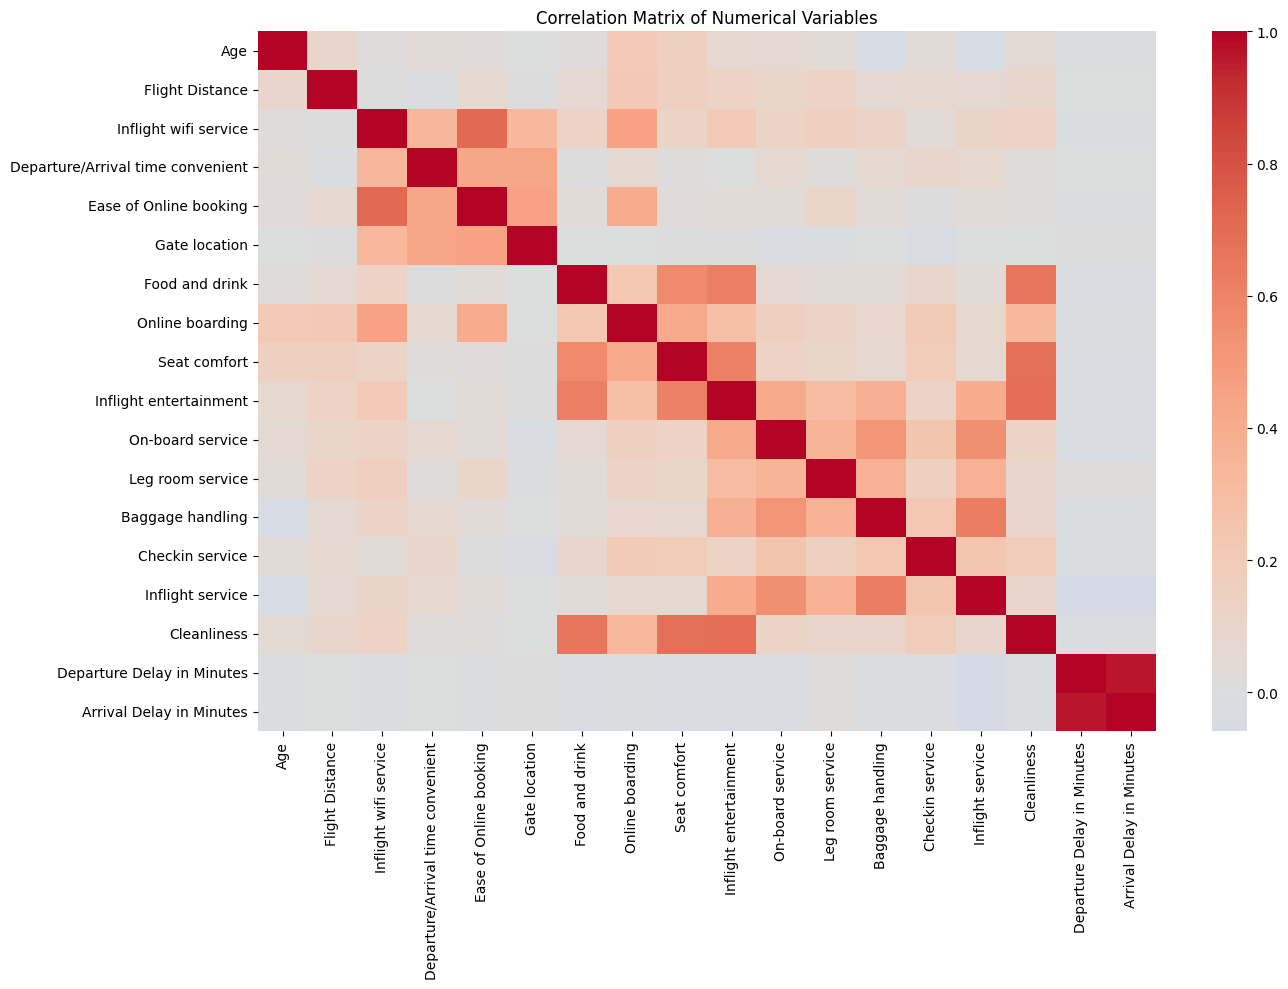

In [32]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

In [33]:
delay_correlations = correlation_matrix[
    [
        "Departure Delay in Minutes",
        "Arrival Delay in Minutes"
    ]
].round(2)

delay_correlations

,Departure Delay in Minutes,Arrival Delay in Minutes
Age,-0.01,-0.01
Flight Distance,0.00,-0.00
Inflight wifi service,-0.02,-0.02
Departure/Arrival time convenient,0.00,-0.00
Ease of Online booking,-0.01,-0.01
Gate location,0.01,0.01
Food and drink,-0.03,-0.03
Online boarding,-0.02,-0.02
Seat comfort,-0.03,-0.03
Inflight entertainment,-0.03,-0.03


### Finding

The correlation matrix provides an overview of relationships between the numerical variables in the dataset.

The results show that some numerical variables have stronger relationships with each other than others. In particular, the relationship between departure and arrival delays is relevant to the investigation of flight delays.

The correlation results are used as exploratory evidence and should not be interpreted as proof of causation.

## Key EDA Findings

The exploratory analysis findings are summarised below. These findings bring together the main patterns identified across passenger characteristics, travel characteristics, service ratings and flight delays.

In [34]:
print("Overall satisfaction:")
print((df["satisfaction"].value_counts(normalize=True) * 100).round(2))
print()

print("Average age by satisfaction:")
print(df.groupby("satisfaction")["Age"].mean().round(2))
print()

print("Average flight distance by satisfaction:")
print(df.groupby("satisfaction")["Flight Distance"].mean().round(2))
print()

print("Average delays by satisfaction:")
print(
    df.groupby("satisfaction")[
        [
            "Departure Delay in Minutes",
            "Arrival Delay in Minutes"
        ]
    ].mean().round(2)
)
print()

print("Satisfaction by Type of Travel:")
print(
    pd.crosstab(
        df["Type of Travel"],
        df["satisfaction"],
        normalize="index"
    ).mul(100).round(2)
)
print()

print("Satisfaction by Travel Class:")
print(
    pd.crosstab(
        df["Class"],
        df["satisfaction"],
        normalize="index"
    ).mul(100).round(2)
)
print()

print("Top five service-rating differences:")
print(service_difference.head(5).round(2))

Overall satisfaction:
satisfaction
neutral or dissatisfied    56.66
satisfied                  43.34
Name: proportion, dtype: float64

Average age by satisfaction:
satisfaction
neutral or dissatisfied    37.57
satisfied                  41.75
Name: Age, dtype: float64

Average flight distance by satisfaction:
satisfaction
neutral or dissatisfied     928.61
satisfied                  1530.18
Name: Flight Distance, dtype: float64

Average delays by satisfaction:
                         Departure Delay in Minutes  Arrival Delay in Minutes
satisfaction                                                                 
neutral or dissatisfied                       16.43                     17.13
satisfied                                     12.55                     12.63

Satisfaction by Type of Travel:
satisfaction     neutral or dissatisfied  satisfied
Type of Travel                                     
Business travel                    41.74      58.26
Personal Travel                   

In [35]:
print(
    pd.crosstab(
        df["Type of Travel"],
        df["satisfaction"],
        normalize="index"
    ).mul(100).round(2).to_string()
)

satisfaction     neutral or dissatisfied  satisfied
Type of Travel                                     
Business travel                    41.74      58.26
Personal Travel                    89.84      10.16


In [36]:
print(
    pd.crosstab(
        df["Class"],
        df["satisfaction"],
        normalize="index"
    ).mul(100).round(2).to_string()
)

satisfaction  neutral or dissatisfied  satisfied
Class                                           
Business                        30.57      69.43
Eco                             81.39      18.61
Eco Plus                        75.42      24.58


## Key EDA Findings

The exploratory analysis identified several important patterns in passenger satisfaction.

- Overall, **43.34% of passengers were satisfied**, while **56.66% were neutral or dissatisfied**, indicating that there is substantial scope for improving the passenger experience.

- Satisfied passengers had a higher average age (**41.75 years**) than neutral or dissatisfied passengers (**37.57 years**).

- Satisfied passengers travelled considerably further on average, with an average flight distance of **1,530.18**, compared with **928.61** for neutral or dissatisfied passengers.

- Average departure and arrival delays were higher among neutral or dissatisfied passengers. Departure delays averaged **16.43 minutes** compared with **12.55 minutes** for satisfied passengers, while arrival delays averaged **17.13 minutes** compared with **12.63 minutes**.

- Type of Travel showed a substantial difference in satisfaction. Among business travellers, **58.26% were satisfied**, compared with only **10.16% of personal travellers**.

- Travel Class also showed a strong descriptive difference. **69.43% of Business Class passengers were satisfied**, compared with **18.61% of Economy passengers** and **24.58% of Eco Plus passengers**.

- Service-rating differences were particularly noticeable for **Online boarding (1.37 points)**, **Inflight entertainment (1.08 points)**, **Seat comfort (0.93 points)**, **On-board service (0.84 points)** and **Leg room service (0.83 points)**.

These findings indicate that travel purpose, travel class, service experience and flight delays are important areas for further investigation. The exploratory results provide the basis for the statistical testing and machine-learning analysis carried out in the following notebooks.

The findings describe patterns and associations in the dataset and should not be interpreted as evidence of causation.

## EDA Conclusion

The exploratory analysis identified several clear patterns in passenger satisfaction across demographic characteristics, travel characteristics, airline service ratings and flight delays.

Overall, **43.34% of passengers were satisfied**, while **56.66% were neutral or dissatisfied**, showing that the neutral or dissatisfied group represented the majority of passengers in the dataset.

Passenger and travel characteristics showed noticeable differences in satisfaction. Satisfied passengers had a higher average age (**41.75 years**) than neutral or dissatisfied passengers (**37.57 years**) and travelled a greater average flight distance (**1,530.18** compared with **928.61**). Business travellers also showed substantially higher satisfaction than personal travellers, while Business Class passengers had higher satisfaction than Eco and Eco Plus passengers.

The service-rating analysis identified particularly large differences between satisfaction groups. **Online boarding** showed the largest difference in average rating at **1.37 points**, followed by Inflight entertainment, Seat comfort, On-board service and Leg room service. These results highlight digital services and aspects of the onboard experience as important areas for further investigation.

Flight delays were strongly right-skewed, with most passengers experiencing little or no delay while a smaller number experienced much larger delays. Neutral or dissatisfied passengers had higher average departure and arrival delays than satisfied passengers, although delays represent only one aspect of the overall passenger experience.

Overall, the EDA identified meaningful patterns across passenger characteristics, travel factors, service ratings and delays. These findings provide a basis for the next stage of the analysis, where selected relationships are examined using statistical hypothesis testing and passenger satisfaction is investigated using machine-learning techniques.

The findings from this exploratory analysis describe patterns and associations within the dataset and should not be interpreted as evidence of causation.